In [1]:
import torch
import torch.nn as nn
import torchsde
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from torch.utils.data import DataLoader
import lightning as pl
import os
from dotenv import load_dotenv; load_dotenv()
%cd {os.getenv('PROJECT_PATH')}

from control.neuralsde import KernelSDE
from control.data import TimeSeriesDataset
from control.training import SDELightningModule, SDEWrapper
from control.contoller import StepController
from control.model import LinearControlSDE

/home/id94ebid/projects/neuroscience


In [2]:
batch_size = 128
num_workers = 1
state_size = 2
control_size = 1
wlen_train = 10
hidden_size = 32
hidden_layers = 1
lr = 1e-2
method = "euler"
dt = 1e-2

In [3]:
train_set = np.load("data_processed/control/train.npz")
test_set = np.load("data_processed/control/test.npz")
ts = train_set["t"]

train_dataset = TimeSeriesDataset(train_set, duplicate=100, window_length=wlen_train)
test_dataset = TimeSeriesDataset(test_set, window_length=200)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)    
val_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

In [ ]:
lighting = SDELightningModule(state_size, control_size, hidden_size, hidden_layers, controller_type='step', lr=lr, method=method, dt=dt)

checkpoint_callback = pl.pytorch.callbacks.ModelCheckpoint(monitor='val_loss', dirpath='checkpoints/', filename='sde-{epoch:02d}-{val_loss:.4f}', save_top_k=1, mode='min')
trainer = pl.Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    callbacks=[
        checkpoint_callback,
        pl.pytorch.callbacks.EarlyStopping(monitor='val_loss', patience=20, mode='min')
    ],
    logger=pl.pytorch.loggers.WandbLogger(project='sde_training', name='sde_run', save_dir='logs/'),
    #gradient_clip_val=10.0,
    log_every_n_steps=10
)   
trainer.fit(lighting, train_loader, val_loader)

# best_model_path = checkpoint_callback.best_model_path
# print(f"Best model saved at: {best_model_path}")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
wandb: Currently logged in as: dani2442 (dani2442-fau) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/home/id94ebid/projects/neuroscience/.venv/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory /home/id94ebid/projects/neuroscience/checkpoints exists and is not empty.

  | Name        | Type       | Params | Mode 
---------------------------------------------------
0 | sde_wrapper | SDEWrapper | 302    | train
---------------------------------------------------
302       Trainable params
0         Non-trainable params
302       Total params
0.001     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/id94ebid/projects/neuroscience/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/home/id94ebid/projects/neuroscience/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

wandb: 502 encountered (
wandb: <html><head>
wandb: <meta http-equiv="content-type" content="text/html;charset=utf-8">
wandb: <title>502 Server Error</title>
wandb: </head>
wandb: <body text=#000000 bgcolor=#ffffff>
wandb: <h1>Error: Server Error</h1>
wandb: <h2>The server encountered a temporary error and could not complete your request.<p>Please try again in 30 seconds.</h2>
wandb: <h2></h2>
wandb: </body></html>), retrying request


/home/id94ebid/projects/neuroscience/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Epoch 2:  45%|████▍     | 105/235 [00:10<00:12, 10.22it/s, v_num=cs0a, train_loss=0.00221, lr=0.010, val_loss=0.157] 

In [ ]:
x, u, ts = next(iter(train_loader))
x0 = x[:,0]
with torch.no_grad():
    ys = lighting(x0, ts, u).transpose(1,0)

/home/id94ebid/projects/neuroscience/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


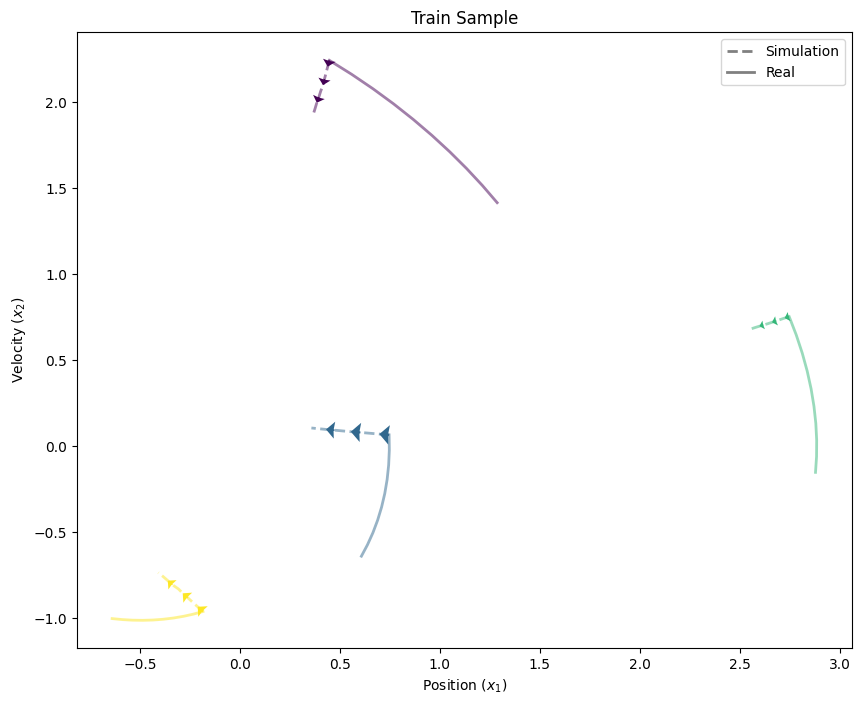

In [ ]:
ts_np = ts[0].detach().numpy()
ys_np = ys.detach().numpy()
xs_np = x.transpose(1,0).detach().numpy()

# Phase portrait
plt.figure(figsize=(10, 8))
num = 4
# Create a grid for the vector field
x1_range = np.linspace(ys_np[:, :, 0].min(), ys_np[:, :, 0].max()+0.01, 100)
x2_range = np.linspace(ys_np[:, :, 1].min(), ys_np[:, :, 1].max(), 100)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Plot trajectories
colors = plt.cm.viridis(np.linspace(0, 1, num))
for i in range(batch_size):
    if i>=num: break
    plt.plot(ys_np[:,i,0], ys_np[:,i,1], alpha=0.5, linewidth=2, color=colors[i], linestyle='--')
    plt.plot(xs_np[:,i,0], xs_np[:,i,1], alpha=0.5, linewidth=2, color=colors[i])

    arrow_idx = np.arange(0, len(ys_np)-1, len(ys_np)//3)
    plt.quiver(ys_np[arrow_idx,i, 0], ys_np[arrow_idx,i, 1],
               ys_np[arrow_idx+1,i, 0] - ys_np[arrow_idx,i, 0],
               ys_np[arrow_idx+1,i, 1] - ys_np[arrow_idx,i, 1],
               color=colors[i], scale_units='xy', angles='xy', scale=1, width=0.003, headwidth=10)

plt.xlabel('Position ($x_1$)')
plt.ylabel('Velocity ($x_2$)')
plt.title('Train Sample')
#plt.grid(True, alpha=0.3)
#plt.xticks([]); plt.yticks([])
legend_elements = [
    Line2D([0], [0], color='gray', linewidth=2, linestyle='--', label='Simulation'),
    Line2D([0], [0], color='gray', linewidth=2, linestyle='-', label='Real')
]
plt.legend(handles=legend_elements,loc='upper right')
plt.savefig('images/node_training_set.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
x, u, ts = next(iter(val_loader))
x0 = x[:,0]
with torch.no_grad():
    ys = lighting(x0, ts,u).transpose(1,0)

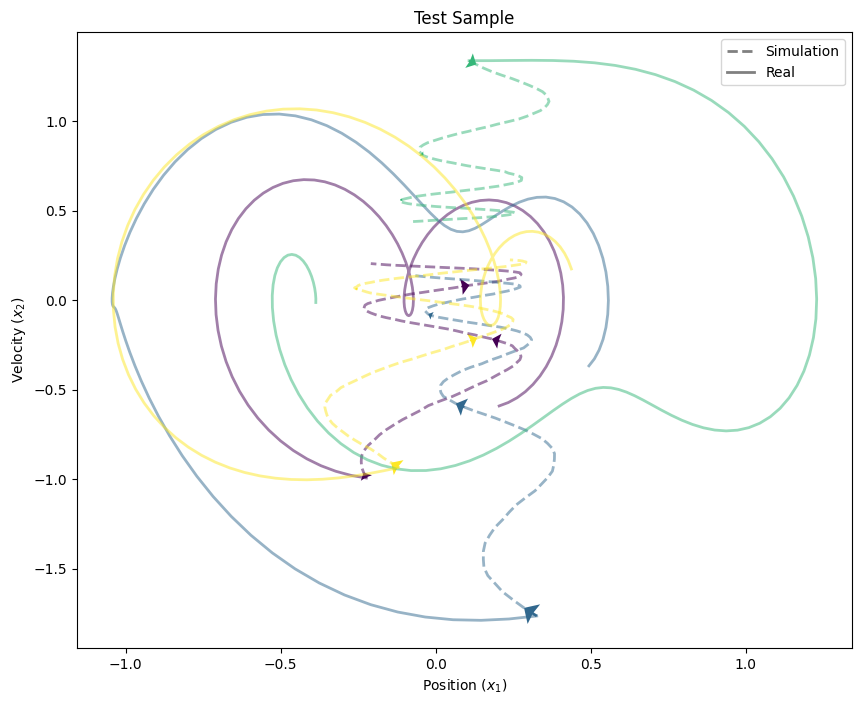

In [ ]:
ts_np = ts[0].detach().numpy()
ys_np = ys.detach().numpy()
xs_np = x.transpose(1,0).detach().numpy()

# Phase portrait
plt.figure(figsize=(10, 8))
num = 4
# Create a grid for the vector field
x1_range = np.linspace(ys_np[:, :, 0].min(), ys_np[:, :, 0].max()+0.01, 100)
x2_range = np.linspace(ys_np[:, :, 1].min(), ys_np[:, :, 1].max(), 100)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Plot trajectories
colors = plt.cm.viridis(np.linspace(0, 1, num))
for i in range(batch_size):
    if i>=num: break
    plt.plot(ys_np[:,i,0], ys_np[:,i,1], alpha=0.5, linewidth=2, color=colors[i], linestyle='--')
    plt.plot(xs_np[:,i,0], xs_np[:,i,1], alpha=0.5, linewidth=2, color=colors[i])

    arrow_idx = np.arange(0, len(ys_np)-1, len(ys_np)//3)
    plt.quiver(ys_np[arrow_idx,i, 0], ys_np[arrow_idx,i, 1],
               ys_np[arrow_idx+1,i, 0] - ys_np[arrow_idx,i, 0],
               ys_np[arrow_idx+1,i, 1] - ys_np[arrow_idx,i, 1],
               color=colors[i], scale_units='xy', angles='xy', scale=1, width=0.003, headwidth=10)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', linewidth=2, linestyle='--', label='Simulation'),
    Line2D([0], [0], color='gray', linewidth=2, linestyle='-', label='Real')
]
plt.xlabel('Position ($x_1$)')
plt.ylabel('Velocity ($x_2$)')
plt.title('Test Sample')
plt.legend(handles=legend_elements, loc='upper right')
plt.savefig('images/node_validation_set.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
m, k, c = 1.0, 1.0, 0.5
A = torch.tensor([[0.0, 1.0],[-k/m, -c/m]])
B = torch.tensor([[0.0], [1.0/m]])
control_input = StepController()
real_model = LinearControlSDE(A, B, control_input=control_input, sigma=0.0)
sde_wrapper_real = SDEWrapper(
    real_model,
    method=method,
    dt=0.01
)

In [ ]:
x, u, ts = next(iter(val_loader))
x0 = x[:,0]
with torch.no_grad():
    ys = sde_wrapper_real(x0, ts, u).transpose(1,0)

/tmp/ipykernel_70396/1007269189.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


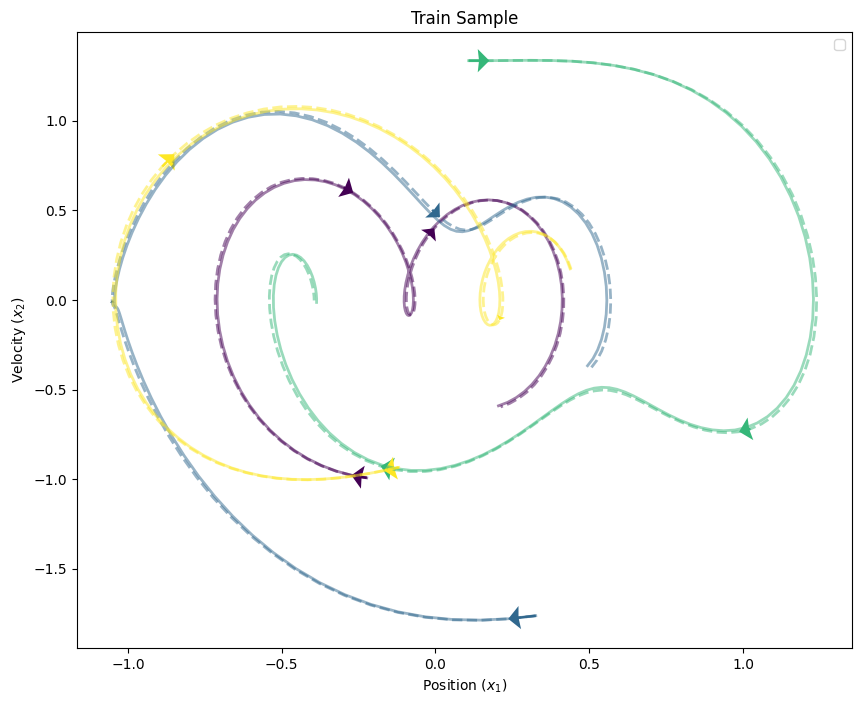

In [ ]:
ts_np = ts[0].detach().numpy()
ys_np = ys.detach().numpy()
xs_np = x.transpose(1,0).detach().numpy()

# Phase portrait
plt.figure(figsize=(10, 8))
num = 4
# Create a grid for the vector field
x1_range = np.linspace(ys_np[:, :, 0].min(), ys_np[:, :, 0].max()+0.01, 100)
x2_range = np.linspace(ys_np[:, :, 1].min(), ys_np[:, :, 1].max(), 100)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Plot trajectories
colors = plt.cm.viridis(np.linspace(0, 1, num))
for i in range(batch_size):
    if i>=num: break
    plt.plot(ys_np[:,i,0], ys_np[:,i,1], alpha=0.5, linewidth=2, color=colors[i], linestyle='--')
    plt.plot(xs_np[:,i,0], xs_np[:,i,1], alpha=0.5, linewidth=2, color=colors[i])

    arrow_idx = np.arange(0, len(ys_np)-1, len(ys_np)//3)
    plt.quiver(ys_np[arrow_idx,i, 0], ys_np[arrow_idx,i, 1],
               ys_np[arrow_idx+1,i, 0] - ys_np[arrow_idx,i, 0],
               ys_np[arrow_idx+1,i, 1] - ys_np[arrow_idx,i, 1],
               color=colors[i], scale_units='xy', angles='xy', scale=1, width=0.003, headwidth=10)

plt.xlabel('Position ($x_1$)')
plt.ylabel('Velocity ($x_2$)')
plt.title('Train Sample')
#plt.grid(True, alpha=0.3)
#plt.xticks([]); plt.yticks([])
plt.legend(loc='upper right')
plt.savefig('images/real_model_validation_set.png', dpi=300, bbox_inches='tight')
plt.show()